# Loading & Exploratory Data Analysis  

Loading `crosstalk_train.parquet` (labelled DEL training data) and `crosstalk_test_inputs.parquet` (the unlabelled ASMS test set), and exploring what we're working with before modelling.


---

## 1. Loading 

Key things to note from examining files:
- **Fingerprints are comma-separated strings** — must be parsed to vectors
- **Label is `DELLabel`**; `RawCount` is the raw enrichment signal it was derived from
- **No SMILES** — overlap checks use fingerprint identity
- **Test is unlabelled** — label-based analyses are train-only; test is characterised in feature space

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import umap
from scipy.sparse import csr_matrix
from sklearn.decomposition import PCA

def parse_fp(s):
    """Comma-separated bit-string -> float32 vector."""
    return np.array(s.split(","), dtype=np.float32)

def fp_matrix(df, fp):
    """Parse a fingerprint column into a sparse (n x 2048) matrix."""
    return csr_matrix(np.stack(df[fp].map(parse_fp).to_numpy()))

TRAIN_PATH = "../input_data/raw/crosstalk_train.parquet"
TEST_PATH  = "../input_data/raw/crosstalk_test_inputs.parquet"

In [ ]:
train = pd.read_parquet(TRAIN_PATH)
test  = pd.read_parquet(TEST_PATH)

# standardize the lipophilicity column name (train: ALOGP, test: AlogP)
if "AlogP" in test.columns:
    test = test.rename(columns={"AlogP": "ALOGP"})

print("train:", train.shape, "| columns:", list(train.columns))
print("test :", test.shape,  "| columns:", list(test.columns))

train: (375595, 16) | columns: ['ID', 'DEL_ID', 'DELLabel', 'RawCount', 'Target', 'ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'ATOMPAIR', 'TOPTOR', 'MW', 'ALOGP']
test : (339258, 12) | columns: ['RandomID', 'ECFP4', 'ECFP6', 'FCFP4', 'FCFP6', 'MACCS', 'RDK', 'AVALON', 'TOPTOR', 'ATOMPAIR', 'MW', 'ALOGP']


In [3]:
X = fp_matrix(train.head(2000), "ECFP4")
print("parsed ECFP4 matrix:", X.shape)               # expect (2000, 2048)
print("max value:", X.max(), "| min:", X.min())
print("=> binary" if X.max() == 1 else "=> counts (values > 1)")
print("avg bits on per molecule:", round(X.getnnz() / X.shape[0], 1))

parsed ECFP4 matrix: (2000, 2048)
max value: 18.0 | min: 0.0
=> counts (values > 1)
avg bits on per molecule: 65.6


---

## 2. Molecular properties: do train and test share chemical space?

Test is unlabelled, so I compared the two **datasets** (covariate-shift check), then looked also at hits-vs-non-hits **within the labelled train set only**.

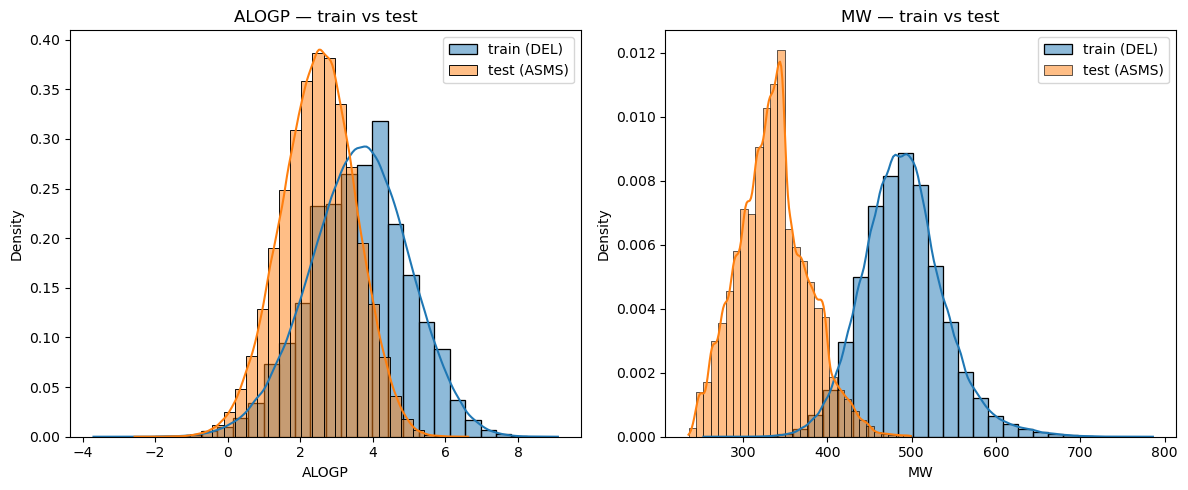

In [3]:
#train vs test overlay:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for data, name, color in [(train, "train (DEL)", "#1f77b4"),
                          (test,  "test (ASMS)", "#ff7f0e")]:
    sns.histplot(data=data, x="ALOGP", kde=True, bins=30, ax=axes[0],
                 stat="density", common_norm=False, color=color, label=name, alpha=0.5)
    sns.histplot(data=data, x="MW", kde=True, bins=30, ax=axes[1],
                 stat="density", common_norm=False, color=color, label=name, alpha=0.5)
axes[0].set_title("ALOGP — train vs test"); axes[0].legend()
axes[1].set_title("MW — train vs test");    axes[1].legend()
plt.tight_layout(); plt.show()

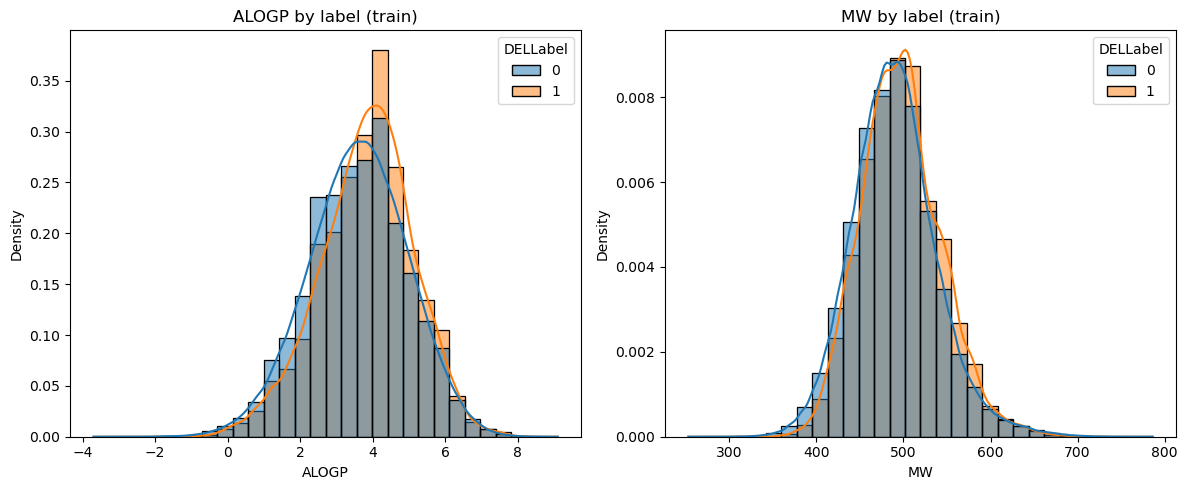

In [4]:
#by-label within train:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.histplot(data=train, x="ALOGP", hue="DELLabel", kde=True, bins=30,
             stat="density", common_norm=False, ax=axes[0])
axes[0].set_title("ALOGP by label (train)")
sns.histplot(data=train, x="MW", hue="DELLabel", kde=True, bins=30,
             stat="density", common_norm=False, ax=axes[1])
axes[1].set_title("MW by label (train)")
plt.tight_layout(); plt.show()

<u>**FINDINGS:**</u>
- **Train vs test (covariate shift):** train (DEL) centers at MW ~490 / ALOGP ~4; test (ASMS) centers at MW ~330 / ALOGP ~2.5 → test molecules are smaller and less lipophilic, overlaps train only in the tails. So model will extrapolate on much of the test set
- **Hits vs non-hits (in train):** nearly identical MW/ALOGP distributions → binding is *not* a bulk-property effect, so the model must learn structure

**Decision:** exclude MW/ALOGP from model features; weak within-train signal and is shifted between train/test data sets

---

## 3. Class imbalance

DEL screens flag relatively few binders among many non-binders, so before modelling we need to know *how* imbalanced the training labels are — as it will shape both the metric and the model setup.

I checked the train set only (test set is unlabelled)

In [5]:
counts = train["DELLabel"].value_counts()
ratio  = train["DELLabel"].value_counts(normalize=True)
print("DEL train class balance:")
print(ratio.round(4))
print("counts:", counts.to_dict())
print(f"1 hit per {ratio[0]/ratio[1]:.1f} non-hits")

DEL train class balance:
DELLabel
0    0.9234
1    0.0766
Name: proportion, dtype: float64
counts: {0: 346817, 1: 28778}
1 hit per 12.1 non-hits


<u>**FINDINGS:**</u>  
7.66% hits (28,778 / 375,595) — 1 hit per ~12 non-hits.

Low hit rate determines:
- **Metric choice** — at low positive rates, accuracy and AUROC are misleading (a model predicting "all non-hit" scores well while finding nothing). We'll use **AUPRC and precision@k**, whose baselines scale with the hit rate.
- **Model setup** — class weighting (`class_weight="balanced"` / `scale_pos_weight`) so the rare positives aren't ignored during training.

Moderate imbalance, and importantly not extreme; with ~29k positives, the minority class is well-populated. Calls for just **class weighting**, not aggressive resampling (no need to discard data).

> The hit rate (0.077) is the random baseline that AUPRC is measured against in later notebooks

---

## 4. Train/test overlap

Quick check to see if any test molecules appear in the training data.  

Overlap would mean the model would benefit from memorization rather than generalization. With no SMILES, we match based on **fingerprint identity** — identical molecules have identical fingerprint strings, so I compared the raw `ECFP4` strings directly (no parsing needed).

In [6]:
train_keys = set(train["ECFP4"])
test_in_train = test["ECFP4"].isin(train_keys)
print(f"test molecules also in train: {test_in_train.sum()} ({test_in_train.mean():.2%} of test)")

test molecules also in train: 0 (0.00% of test)


<u>**FINDINGS:**</u>  
**0 overlap**, no test molecule appears in training.  
So submission performance will reflect true generalization, not memorization.

---

## 5. Chemical space: UMAP
Project the fingerprints to 2D to see structure. 

<u>Two views used</u>: train coloured by hit (does ECFP4 separate binders?) and a joint train+test embedding coloured by dataset (does test chemistry overlap train?).

> Fingerprints are **counts**, but Jaccard/Tanimoto similarity is defined on binary sets, so I binarized (`> 0`) before embedding.  
> UMAP is also slow on 375k rows, so subsample.

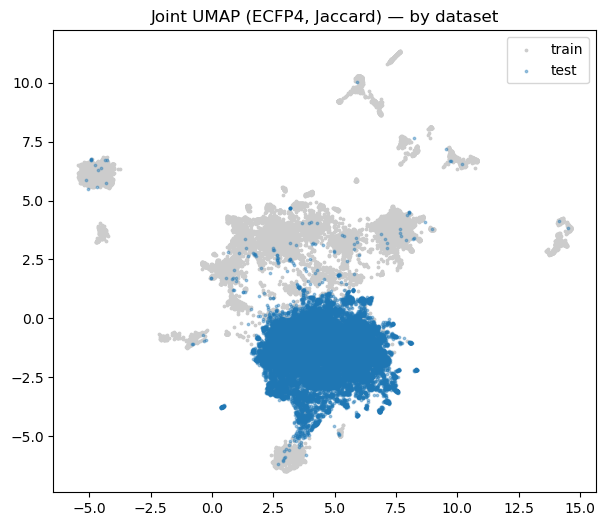

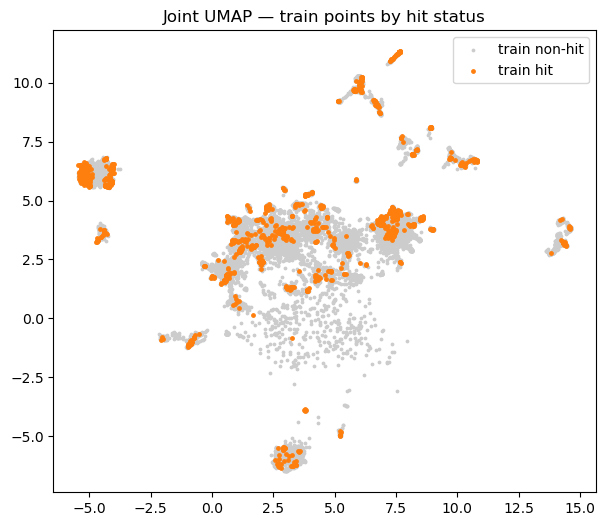

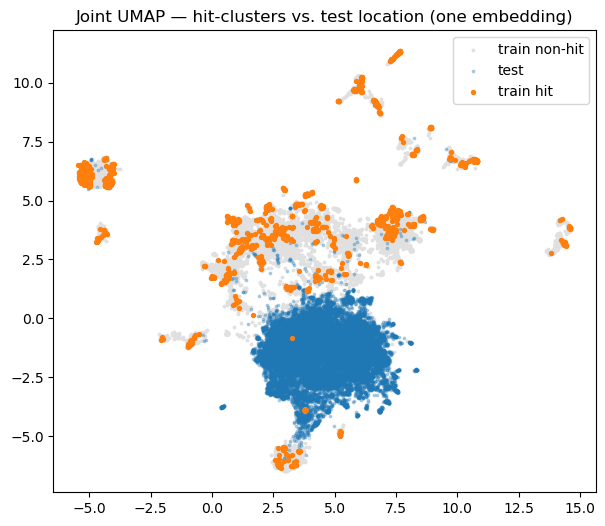

In [8]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="umap")

# ---- One joint train+test UMAP embedding, plotted multiple ways ----
# (single fit_transform so hit-structure and test-location share one coordinate system)
rng = np.random.default_rng(42)
n_each = 20000
tr_j = rng.choice(len(train), n_each, replace=False)
te_j = rng.choice(len(test),  n_each, replace=False)

Xb_j = np.vstack([
    (fp_matrix(train.iloc[tr_j], "ECFP4").toarray() > 0).astype(np.int8),
    (fp_matrix(test.iloc[te_j],  "ECFP4").toarray() > 0).astype(np.int8),
])
src     = np.array(["train"]*n_each + ["test"]*n_each)
hit_tr  = train["DELLabel"].to_numpy()[tr_j]          # hit labels for the train half
is_train = src == "train"
is_test  = src == "test"

emb_j = umap.UMAP(n_neighbors=20, min_dist=0.1, metric="jaccard",
                  random_state=42).fit_transform(Xb_j)

# --- Plot 1: by dataset (where does test land?) ---
plt.figure(figsize=(7, 6))
plt.scatter(emb_j[is_train,0], emb_j[is_train,1], s=3, c="#cccccc", label="train")
plt.scatter(emb_j[is_test,0],  emb_j[is_test,1],  s=3, c="#1f77b4", alpha=0.4, label="test")
plt.legend(); plt.title("Joint UMAP (ECFP4, Jaccard) — by dataset"); plt.show()

# --- Plot 2: SAME embedding, train points by hit status (where are the clean hit-clusters?) ---
plt.figure(figsize=(7, 6))
tr_emb = emb_j[is_train]
plt.scatter(tr_emb[hit_tr==0,0], tr_emb[hit_tr==0,1], s=3, c="#cccccc", label="train non-hit")
plt.scatter(tr_emb[hit_tr==1,0], tr_emb[hit_tr==1,1], s=6, c="#ff7f0e", label="train hit")
plt.legend(); plt.title("Joint UMAP — train points by hit status"); plt.show()

# --- Plot 3: the combined view — hit-clusters AND test location in ONE coordinate system ---
plt.figure(figsize=(7, 6))
plt.scatter(tr_emb[hit_tr==0,0], tr_emb[hit_tr==0,1], s=3, c="#e0e0e0", label="train non-hit")
plt.scatter(emb_j[is_test,0],    emb_j[is_test,1],    s=3, c="#1f77b4", alpha=0.3, label="test")
plt.scatter(tr_emb[hit_tr==1,0], tr_emb[hit_tr==1,1], s=8, c="#ff7f0e", label="train hit")  # hits on top
plt.legend(); plt.title("Joint UMAP — hit-clusters vs. test location (one embedding)"); plt.show()

<u>**FINDINGS:</u>**

Combined train and test *together* (one coordinate system) and viewing it three ways:
- **By hit status (train):** ECFP4 shows a real signal — training hits concentrate in distinct clusters in the upper region of the embedding; there is a large central/lower area where hits are sparse (possibly DEL's label-noisy region)
- **By dataset:** the test data concentrate into a single dense region in the lower-center
- **Combined:** the test region sits **largely away from the hit-enriched train clusters**; instead, in the hit-sparse lower zone. The few training hits near the test blob would be the structurally-reachable ones; most training hits cluster elsewhere, in areas the test set barely occupies.

**Implication:** **Hard transfer** → The model will learn the hit boundary most reliably in the dense train hit-clusters, but must make predictions in the hit-sparse region where the test lives. 

**Decision:** Filtering training down to test-like chemistry would discard most of the reliable hit signal, so will continue on with the full dataset

---

## EDA summary — what this means for down-stream modelling

| OBSERVATION | IMPLICATION |
|---|---|
| Train ~MW 490 / ALOGP 4 vs Test ~MW 330 / ALOGP 2.5 | Strong _covariate shift_ — model must extrapolate to lighter, more polar test chemistry |
| DEL hits ≈ non-hits, on MW/ALOGP | Exclude MW/ALOGP as features (no within-set signal and was shifted across data sets) |
| 7.66% hit rate (~29k positives) | Use class weighting (not resampling); evaluate with AUPRC and precision@k, not accuracy |
| From UMAP, training hits form distinct clusters. But test data is concentrated in a hit-sparse region _away from those clusters_ | Hard transfer — test occupies chemistry where DEL hit-labels are scarce, so the model will need to predicts where hit signal is weakest |

### Preprocessing decision: no train-set filtering

I considered removing training compounds dissimilar to the test ("applicability-domain filtering"), motivated by the covariate shift and DEL's label noise.
But this preprocessing step was rejected, based on the joint UMAP: test data occupies a hit-sparse region, while the training hits are clustering elsewhere. Filtering the training set down to test-like chemistry would discard most of the reliable hit signal.

---
---

## Next Steps — Notebook 2: Model Selection and Baseline Pipeline

Notebook 2 builds the core ranking pipeline: surveying candidate models, selecting and tuning the strongest into a fingerprint ensemble, diagnosing the DEL→E-ASMS distribution shift, and producing the baseline Kaggle submission. 

All model decisions are validated on the DEL training data with building-block-grouped cross-validation (so that combinatorial DEL siblings won't leak across folds); the E-ASMS test set stays untouched until submission.